<a href="https://colab.research.google.com/github/R229121B-boop/21-MODELS-ASSIGNMENT-CNN-SHINGIRIRAI-MWARUNZIKA-R229121B/blob/main/Final_Dissertation_Code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install scikeras for Keras-Scikit-learn integration
!pip install scikeras[tensorflow]

# Upgrade scikit-learn for compatibility with scikeras
!pip install -U scikit-learn

# Install scikit-plot for plotting ROC curves
!pip install -U scikit-plot

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 76.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
#Importing the basic librarires

import os
import math
import scipy
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm import tqdm
from sklearn import tree
from scipy.stats import randint
from scipy.stats import loguniform
from IPython.display import display

from sklearn.decomposition import PCA
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import RFE
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import RepeatedStratifiedKFold

from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, \
f1_score, roc_auc_score, roc_curve, precision_score, recall_score, mean_squared_error, r2_score
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [10,6]
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 50)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**1.DATA EXPLORATION**

In [ ]:
import pandas as pd

csv_path = '/content/drive/MyDrive/DData.csv'
df = pd.read_csv(csv_path)

target = 'charges'
features = [i for i in df.columns.values if i not in [target]]
original_df = df.copy(deep=True)
display(df.head())
print('\n\033[1mInference:\033[0m The Datset consists of {} features & {} samples.'.format(df.shape[1], df.shape[0]))

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1



Inference: The Datset consists of 8 features & 1338 samples.


In [ ]:
#Checking the dtypes of all the columns

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             1338 non-null   int64  
 1   sex             1338 non-null   int64  
 2   bmi             1338 non-null   float64
 3   children        1338 non-null   int64  
 4   smoker          1338 non-null   int64  
 5   region          1338 non-null   int64  
 6   charges         1338 non-null   float64
 7   insuranceclaim  1338 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 83.8 KB


In [ ]:
#Checking number of unique rows in each feature
df.nunique().sort_values()

,0
sex,2
smoker,2
insuranceclaim,2
region,4
children,6
age,47
bmi,548
charges,1337


In [ ]:
#Checking number of unique rows in each feature

nu = df[features].nunique().sort_values()
nf = []; cf = []; nnf = 0; ncf = 0; #numerical & categorical features

for i in range(df[features].shape[1]):
    if nu.values[i]<=7:cf.append(nu.index[i])
    else: nf.append(nu.index[i])

print('\n\033[1mInference:\033[0m The Datset has {} numerical & {} categorical features.'.format(len(nf),len(cf)))


Inference: The Datset has 2 numerical & 5 categorical features.


**2.Exploratory Data Analysis**

In [ ]:
#Checking the stats of all the columns

display(df.describe())

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,0.505232,30.663397,1.094918,0.204783,1.515695,13270.422265,0.585202
std,14.049960,0.500160,6.098187,1.205493,0.403694,1.104885,12110.011237,0.492871
min,18.000000,0.000000,15.960000,0.000000,0.000000,0.000000,1121.873900,0.000000
25%,27.000000,0.000000,26.296250,0.000000,0.000000,1.000000,4740.287150,0.000000
50%,39.000000,1.000000,30.400000,1.000000,0.000000,2.000000,9382.033000,1.000000
75%,51.000000,1.000000,34.693750,2.000000,0.000000,2.000000,16639.912515,1.000000
max,64.000000,1.000000,53.130000,5.000000,1.000000,3.000000,63770.428010,1.000000


            Target Variable Distribution           


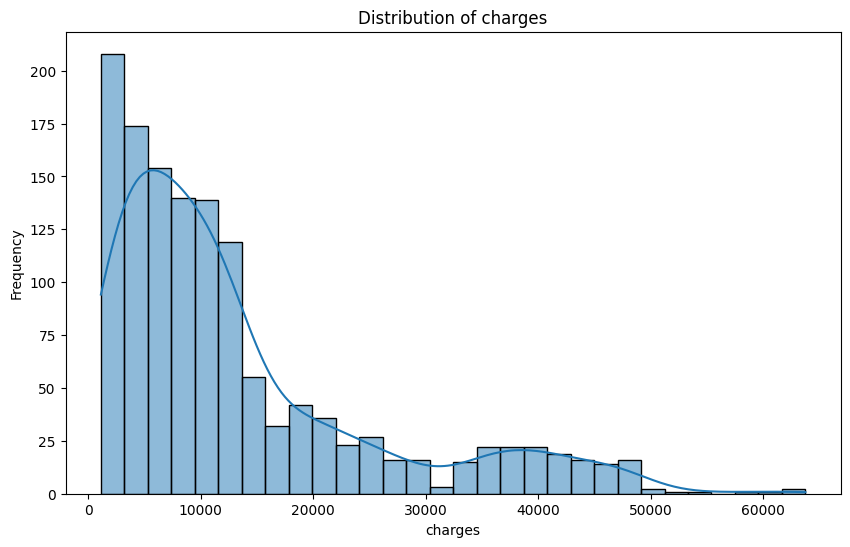


Inference: The target variable, charges, shows a skewed distribution, which is common for claim severity data. This distribution will be handled by the chosen GLM family and the ANN.


In [ ]:
#Analyzying the distribution of the target variable

print('\033[1mTarget Variable Distribution'.center(55))
sns.histplot(df[target], kde=True)
plt.xlabel(target)
plt.ylabel('Frequency')
plt.title(f'Distribution of {target}')
plt.show()

print('\n\033[1mInference:\033[0m The target variable, charges, shows a skewed distribution, which is common for claim severity data. This distribution will be handled by the chosen GLM family and the ANN.')

**Data Visualisation**

                               Visualising Categorical Features:                                


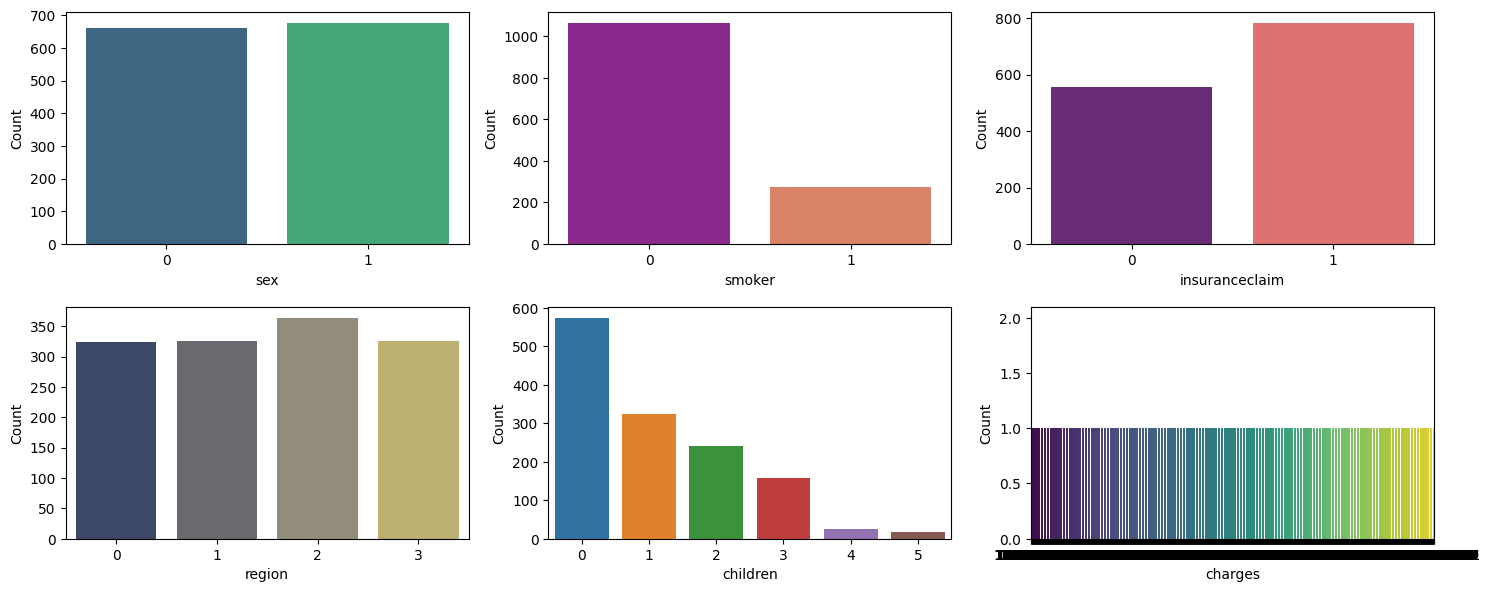


Inference: Visualizing the categorical features reveal lot of information about the dataset.


In [ ]:
print('\033[1mVisualising Categorical Features:'.center(100))

n=3


cf_with_target = cf + [target]

plt.figure(figsize=[15,3*math.ceil(len(cf_with_target)/n)])
palettes = ['viridis', 'plasma', 'magma', 'cividis', 'tab10']

for i in range(len(cf_with_target)):
    plt.subplot(math.ceil(len(cf_with_target)/n),n,i+1)
    sns.countplot(x=df[cf_with_target[i]], palette=palettes[i % len(palettes)])
    plt.xlabel(cf_with_target[i])
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

print('\n\033[1mInference:\033[0m Visualizing the categorical features reveal lot of information about the dataset.'.format(len(nf),len(cf)))

**Data Distribution**

                                     Features Distribution                                      


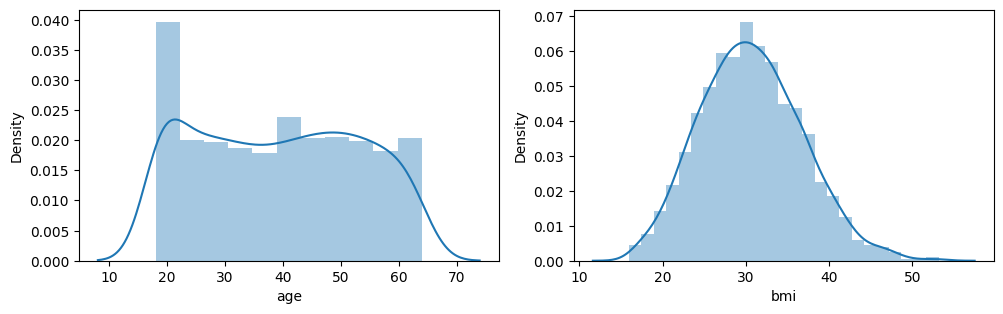

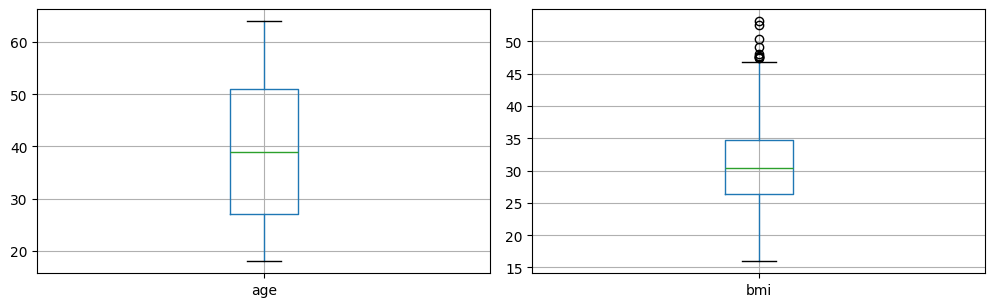


Inference: The data is somewhat normally distributed. And there are many outliers present in the dataset. We shall fix these outliers.


In [ ]:
#Understanding the feature set

print('\033[1mFeatures Distribution'.center(100))

nf = [i for i in features if i not in cf]

plt.figure(figsize=[15,3*math.ceil(len(features)/3)])
for c in range(len(nf)):
    plt.subplot(math.ceil(len(features)/3),3,c+1)
    sns.distplot(df[nf[c]])
plt.tight_layout()
plt.show()
plt.figure(figsize=[15,3*math.ceil(len(features)/3)])
for c in range(len(nf)):
    plt.subplot(math.ceil(len(features)/3),3,c+1)
    df.boxplot(nf[c])
plt.tight_layout()
plt.show()

print('\n\033[1mInference:\033[0m The data is somewhat normally distributed. And there are many outliers present in the dataset. We shall fix these outliers.'.format(len(nf),len(cf)))

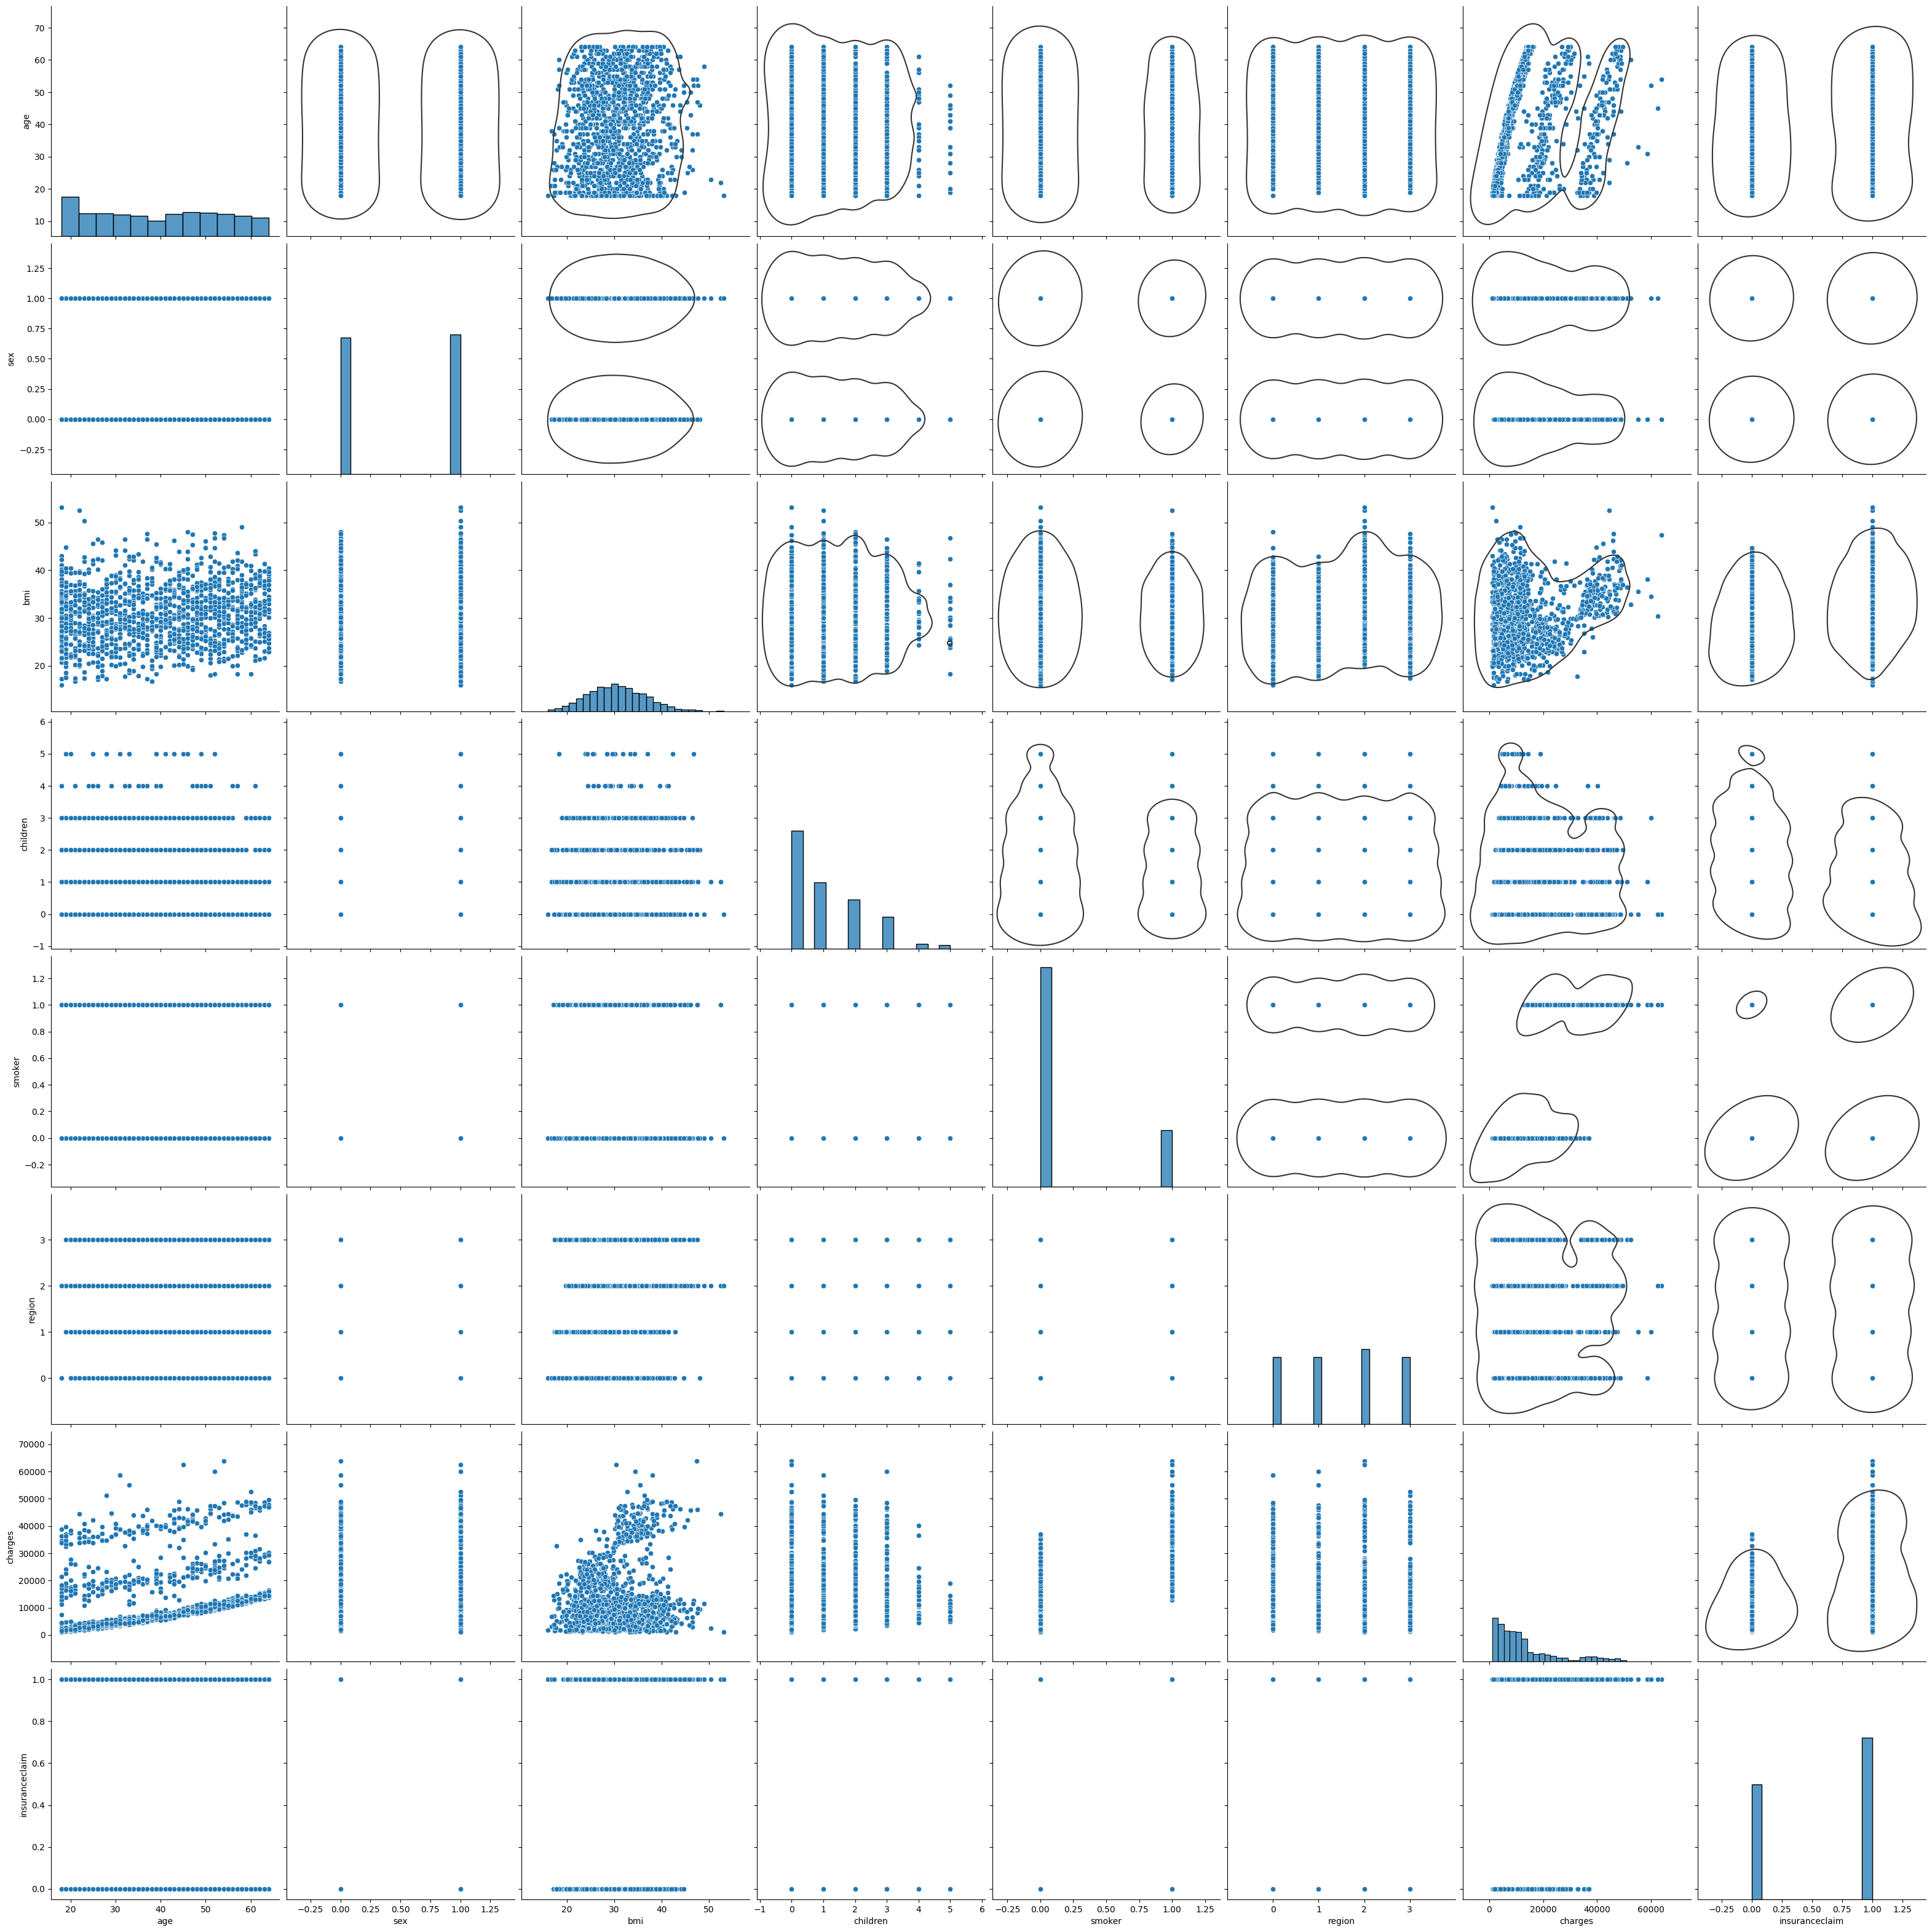


Inference: The data samples of most of the features do show some patterns. Also they seem to have lot of overlap for the outcome classes, making it difficult to be distingusihable. Let is proceed to perform cleanup on the data to remove the irregularities.


In [ ]:
#Understanding the relationship between all the features


df1 = df.copy()
df1.drop_duplicates(inplace=True)

g=sns.pairplot(df1, size=4)
g.map_upper(sns.kdeplot, levels=1, color=".2")
plt.show()

print('\n\033[1mInference:\033[0m The data samples of most of the features do show some patterns. Also they seem to have lot of overlap for the outcome classes, making it difficult to be distingusihable. Let is proceed to perform cleanup on the data to remove the irregularities.'.format(len(nf),len(cf)))

**Data Cleaning**

In [ ]:
#Removal of any Duplicate rows (if any)

counter = 0
r,c = original_df.shape

df1 = df.copy()
df1.drop_duplicates(inplace=True)
df1.reset_index(drop=True,inplace=True)

if df1.shape==(r,c):
    print('\n\033[1mInference:\033[0m The dataset doesn\'t have any duplicates')
else:
    print(f'\n\033[1mInference:\033[0m Number of duplicates dropped ---> {r-df1.shape[0]}')



Inference: Number of duplicates dropped ---> 1


In [ ]:
#Check for empty elements

nvc = pd.DataFrame(df1.isnull().sum().sort_values(), columns=['Total Null Values'])
nvc['Percentage'] = round(nvc['Total Null Values']/df1.shape[0],3)*100
print(nvc)

                Total Null Values  Percentage
age                             0         0.0
sex                             0         0.0
bmi                             0         0.0
children                        0         0.0
smoker                          0         0.0
region                          0         0.0
charges                         0         0.0
insuranceclaim                  0         0.0


In [ ]:
#Converting categorical Columns to Numeric

#df1 = df.copy()
ecc = nvc[nvc['Percentage']!=0].index.values
dcc = [i for i in df.columns if i not in ecc]

df3 = df1[dcc]
fcc = [i for i in cf if i not in ecc]

#One-Hot Binay Encoding
oh=True
dm=True
for i in fcc:
    #print(i)
    if df3[i].nunique()==2:
        if oh==True: print("\033[1m\nOne-Hot Encoding on features:\033[0m")
        print(i);oh=False
        df3[i]=pd.get_dummies(df3[i], drop_first=True, prefix=str(i))
    if (df3[i].nunique()>2 and df3[i].nunique()<17):
        if dm==True: print("\n\033[1mDummy Encoding on features:\033[0m")
        print(i);dm=False
        df3 = pd.concat([df3.drop([i], axis=1), pd.DataFrame(pd.get_dummies(df3[i], drop_first=True, prefix=str(i)))],axis=1)

df3.shape


One-Hot Encoding on features:
sex
smoker
insuranceclaim

Dummy Encoding on features:
region
children


(1337, 14)

In [ ]:
#Removal of outlier:

df4 = df3.copy()

for i in [i for i in df4.columns]:
    if df4[i].nunique()>=12:
        Q1 = df4[i].quantile(0.25)
        Q3 = df4[i].quantile(0.75)
        IQR = Q3 - Q1
        df4 = df4[df4[i] <= (Q3+(1.5*IQR))]
        df4 = df4[df4[i] >= (Q1-(1.5*IQR))]
        df4 = df4.reset_index(drop=True)
display(df4.head())
print('\n\033[1mInference:\033[0m Before removal of outliers, The dataset had {} samples.'.format(df1.shape[0]))
print('\033[1mInference:\033[0m After removal of outliers, The dataset now has {} samples.'.format(df4.shape[0]))

,age,sex,bmi,smoker,charges,insuranceclaim,region_1,region_2,region_3,children_1,children_2,children_3,children_4,children_5
0,19,False,27.900,True,16884.92400,True,False,False,True,False,False,False,False,False
1,18,True,33.770,False,1725.55230,True,False,True,False,True,False,False,False,False
2,28,True,33.000,False,4449.46200,False,False,True,False,False,False,True,False,False
3,33,True,22.705,False,21984.47061,False,True,False,False,False,False,False,False,False
4,32,True,28.880,False,3866.85520,True,True,False,False,False,False,False,False,False



Inference: Before removal of outliers, The dataset had 1337 samples.
Inference: After removal of outliers, The dataset now has 1190 samples.


In [ ]:

# Therefore, we will proceed without SMOTE and directly define X and Y from the cleaned dataframe.

df = df4.copy() # 'df4' is the dataframe after outlier removal

X = df.drop([target],axis=1)
Y = df[target]

print('\n\033[1mInference:\033[0m The feature set (X) and target variable (Y) have been prepared for regression modeling.')


Inference: The feature set (X) and target variable (Y) have been prepared for regression modeling.


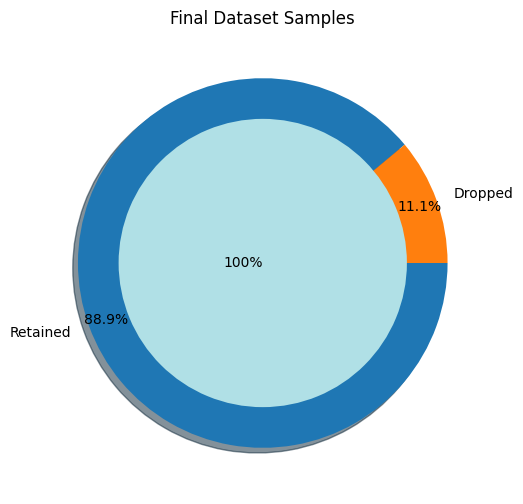


Inference:The final dataset after cleanup has 1190 samples & 14 columns.


In [ ]:
#Final Dataset size after performing Preprocessing

# 'df' already holds the cleaned data from 'df4' at this point.
plt.title('Final Dataset Samples')
plt.pie([df.shape[0], original_df.shape[0] - df.shape[0]], radius = 1, shadow=True,
        labels=['Retained','Dropped'], counterclock=False, autopct='%1.1f%%', pctdistance=0.9, explode=[0,0])
plt.pie([df.shape[0]], labels=['100%'], labeldistance=-0, radius=0.78, shadow=True, colors=['powderblue'])
plt.show()

print('\n\033[1mInference:\033[0mThe final dataset after cleanup has {} samples & {} columns.'.format(df.shape[0], df.shape[1]))

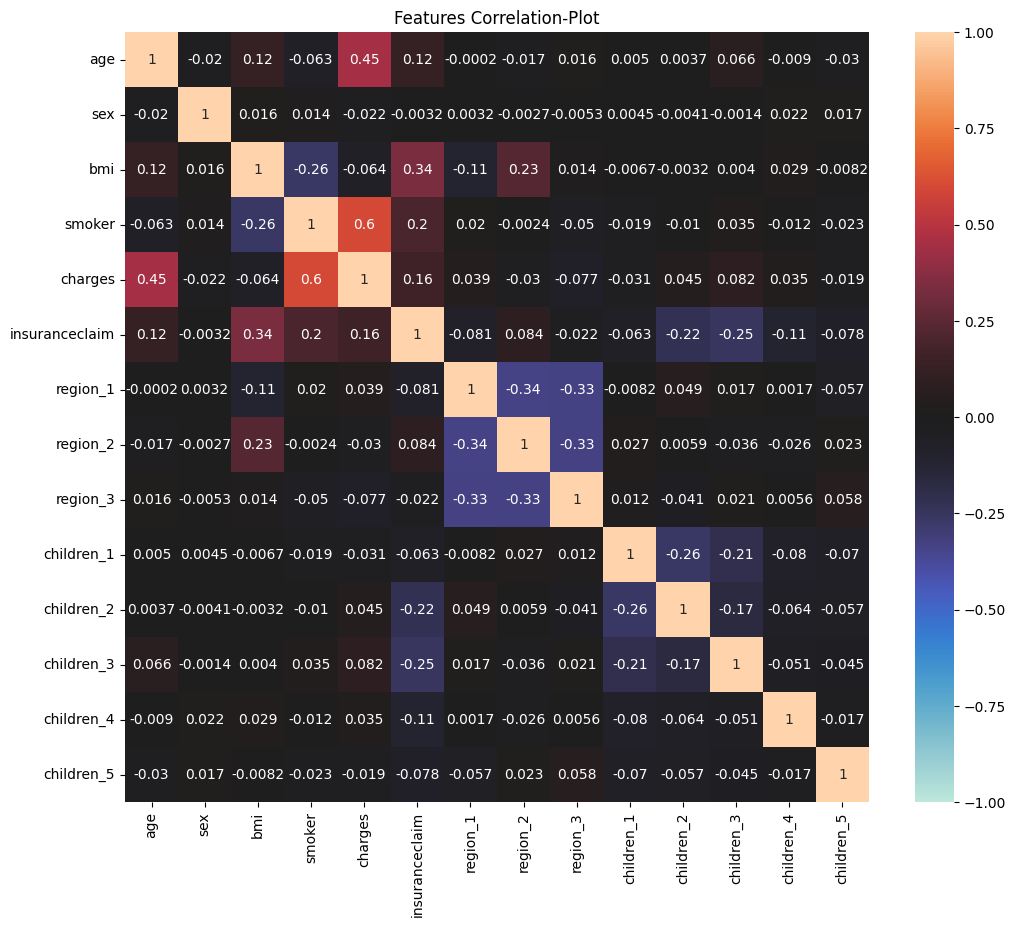


Inference:The heatmap clearly highlights smoker, age, and bmi as the most influential features for predicting charges. This information is crucial for understanding the drivers of insurance costs and for guiding our modeling efforts, especially in terms of feature importance and interpretability of the GLM.


In [ ]:
#Checking the correlation

features = df.columns
plt.figure(figsize=[12,10])
plt.title('Features Correlation-Plot')
sns.heatmap(df[features].corr(), vmin=-1, vmax=1, center=0, annot=True) #,
plt.show()

print('\n\033[1mInference:\033[0mThe heatmap clearly highlights smoker, age, and bmi as the most influential features for predicting charges. This information is crucial for understanding the drivers of insurance costs and for guiding our modeling efforts, especially in terms of feature importance and interpretability of the GLM.'.format(df.shape[0], df.shape[1]))

**HYBRID GLM + ANN MODEL BUILDING**

In [ ]:


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from scikeras.wrappers import KerasRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import RobustScaler
import statsmodels.api as sm
from scipy import stats
import joblib

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

All libraries imported successfully!
TensorFlow version: 2.19.0


**FINAL DATA PREPARATION FOR MODELING**

In [ ]:




# Split data
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Robust scaling (handles outliers better)
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape}")
print(f"Test set: {X_test_scaled.shape}")

Training set: (952, 13)
Test set: (238, 13)


**BUILD AND TRAIN GLM COMPONENTS**

In [ ]:



# GLM 1: Ridge Regression (L2 regularization)
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)
ridge_r2 = r2_score(y_test, ridge_pred)

# GLM 2: Lasso Regression (L1 regularization)
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)
lasso_pred = lasso.predict(X_test_scaled)
lasso_r2 = r2_score(y_test, lasso_pred)

# GLM 3: Statsmodels OLS with robust standard errors
X_train_sm = sm.add_constant(X_train_scaled)
X_test_sm = sm.add_constant(X_test_scaled)
ols_model = sm.OLS(y_train, X_train_sm).fit()
ols_pred = ols_model.predict(X_test_sm)
ols_r2 = r2_score(y_test, ols_pred)

print(f" Ridge R²: {ridge_r2:.4f}")
print(f" Lasso R²: {lasso_r2:.4f}")
print(f" OLS R²: {ols_r2:.4f}")

 Ridge R²: 0.5338
 Lasso R²: 0.5316
 OLS R²: 0.5316


In [ ]:
def create_advanced_ann(input_dim):
    inputs = layers.Input(shape=(input_dim,))

    # Pathway 1: Dense layers with dropout
    x1 = layers.Dense(512, activation='relu')(inputs)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Dropout(0.3)(x1)
    x1 = layers.Dense(256, activation='relu')(x1)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.Dropout(0.2)(x1)

    # Pathway 2: Skip connection with different activation
    x2 = layers.Dense(128, activation='swish')(inputs)
    x2 = layers.Dropout(0.1)(x2)

    # Pathway 3: Attention-like mechanism
    x3 = layers.Dense(64, activation='relu')(inputs)
    x3 = layers.Reshape((1, 64))(x3) # Reshape to add a 'steps' dimension
    x3 = layers.MultiHeadAttention(num_heads=4, key_dim=16)(x3, x3)
    x3 = layers.GlobalAveragePooling1D()(x3)

    # Concatenate pathways
    combined = layers.Concatenate()([x1, x2, x3])

    # Final layers
    x = layers.Dense(128, activation='relu')(combined)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.1)(x)

    # Output layer
    outputs = layers.Dense(1)(x)

    model = keras.Model(inputs, outputs)
    return model

# Create and compile ANN
ann_model = create_advanced_ann(X_train_scaled.shape[1])
ann_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

# Callbacks
early_stopping = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=20, restore_best_weights=True
)
reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=10, min_lr=1e-7
)

# Train ANN
print("\nTraining Advanced ANN...")
ann_history = ann_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=64,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# ANN predictions
ann_pred = ann_model.predict(X_test_scaled, verbose=0).flatten()
ann_r2 = r2_score(y_test, ann_pred)

print(f" ANN R²: {ann_r2:.4f}")


Training Advanced ANN...
Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 18s 633ms/step - loss: 147703424.0000 - mae: 9785.7168 - val_loss: 155329904.0000 - val_mae: 10054.5088 - learning_rate: 0.0010
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 147632544.0000 - mae: 9783.5654 - val_loss: 155314560.0000 - val_mae: 10054.0410 - learning_rate: 0.0010
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 147533952.0000 - mae: 9780.8662 - val_loss: 155287280.0000 - val_mae: 10053.4043 - learning_rate: 0.0010
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 147386992.0000 - mae: 9776.6064 - val_loss: 155278112.0000 - val_mae: 10053.7949 - learning_rate: 0.0010
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 147148320.0000 - mae: 9769.5654 - val_loss: 155327616.0000 - val_mae: 10055.8447 - learning_rate: 0.0010
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 146819248.0000 - mae: 9760.2852 - val_loss: 155326480.0000 - val_mae: 10055.4951 - lear

**HYBRID MODEL ENSEMBLE**

In [ ]:



# Weighted ensemble (optimized weights based on individual R²)
def create_hybrid_ensemble(ridge_pred, lasso_pred, ols_pred, ann_pred, weights=None):
    """Create weighted ensemble of all models"""
    if weights is None:
        # Dynamic weights based on R² performance
        r2_scores = [r2_score(y_test, ridge_pred),
                    r2_score(y_test, lasso_pred),
                    r2_score(y_test, ols_pred),
                    r2_score(y_test, ann_pred)]
        total = sum(r2_scores)
        weights = [score/total for score in r2_scores]

    hybrid_pred = (weights[0]*ridge_pred +
                   weights[1]*lasso_pred +
                   weights[2]*ols_pred +
                   weights[3]*ann_pred)

    return hybrid_pred, weights

# Create hybrid predictions
hybrid_pred, ensemble_weights = create_hybrid_ensemble(
    ridge_pred, lasso_pred, ols_pred, ann_pred
)
hybrid_r2 = r2_score(y_test, hybrid_pred)

print(f" Ensemble Weights: Ridge={ensemble_weights[0]:.3f}, "
      f"Lasso={ensemble_weights[1]:.3f}, OLS={ensemble_weights[2]:.3f}, "
      f"ANN={ensemble_weights[3]:.3f}")
print(f" Hybrid R²: {hybrid_r2:.4f}")

 Ensemble Weights: Ridge=0.258, Lasso=0.257, OLS=0.257, ANN=0.227
 Hybrid R²: 0.5411


**MODEL EVALUATION & COMPARISON**

In [ ]:


def print_metrics(y_true, y_pred, model_name):
    """Print comprehensive metrics"""
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{model_name:15} | R²: {r2:.4f} | RMSE: {rmse:8.1f} | "
          f"MAE: {mae:7.1f} | MAPE: {mape:5.1f}%")

print("\n Test Set Performance:")
print("-" * 80)
print_metrics(y_test, ridge_pred, "Ridge")
print_metrics(y_test, lasso_pred, "Lasso")
print_metrics(y_test, ols_pred, "OLS")
print_metrics(y_test, ann_pred, "ANN")
print_metrics(y_test, hybrid_pred, "HYBRID")
print("-" * 80)


 Test Set Performance:
--------------------------------------------------------------------------------
Ridge           | R²: 0.5338 | RMSE:   4740.2 | MAE:  2700.5 | MAPE:  30.3%
Lasso           | R²: 0.5316 | RMSE:   4751.6 | MAE:  2701.3 | MAPE:  29.8%
OLS             | R²: 0.5316 | RMSE:   4751.7 | MAE:  2701.1 | MAPE:  29.8%
ANN             | R²: 0.4702 | RMSE:   5053.3 | MAE:  3286.0 | MAPE:  44.6%
HYBRID          | R²: 0.5411 | RMSE:   4703.4 | MAE:  2644.2 | MAPE:  28.9%
--------------------------------------------------------------------------------


**ADVANCED VISUALIZATION**

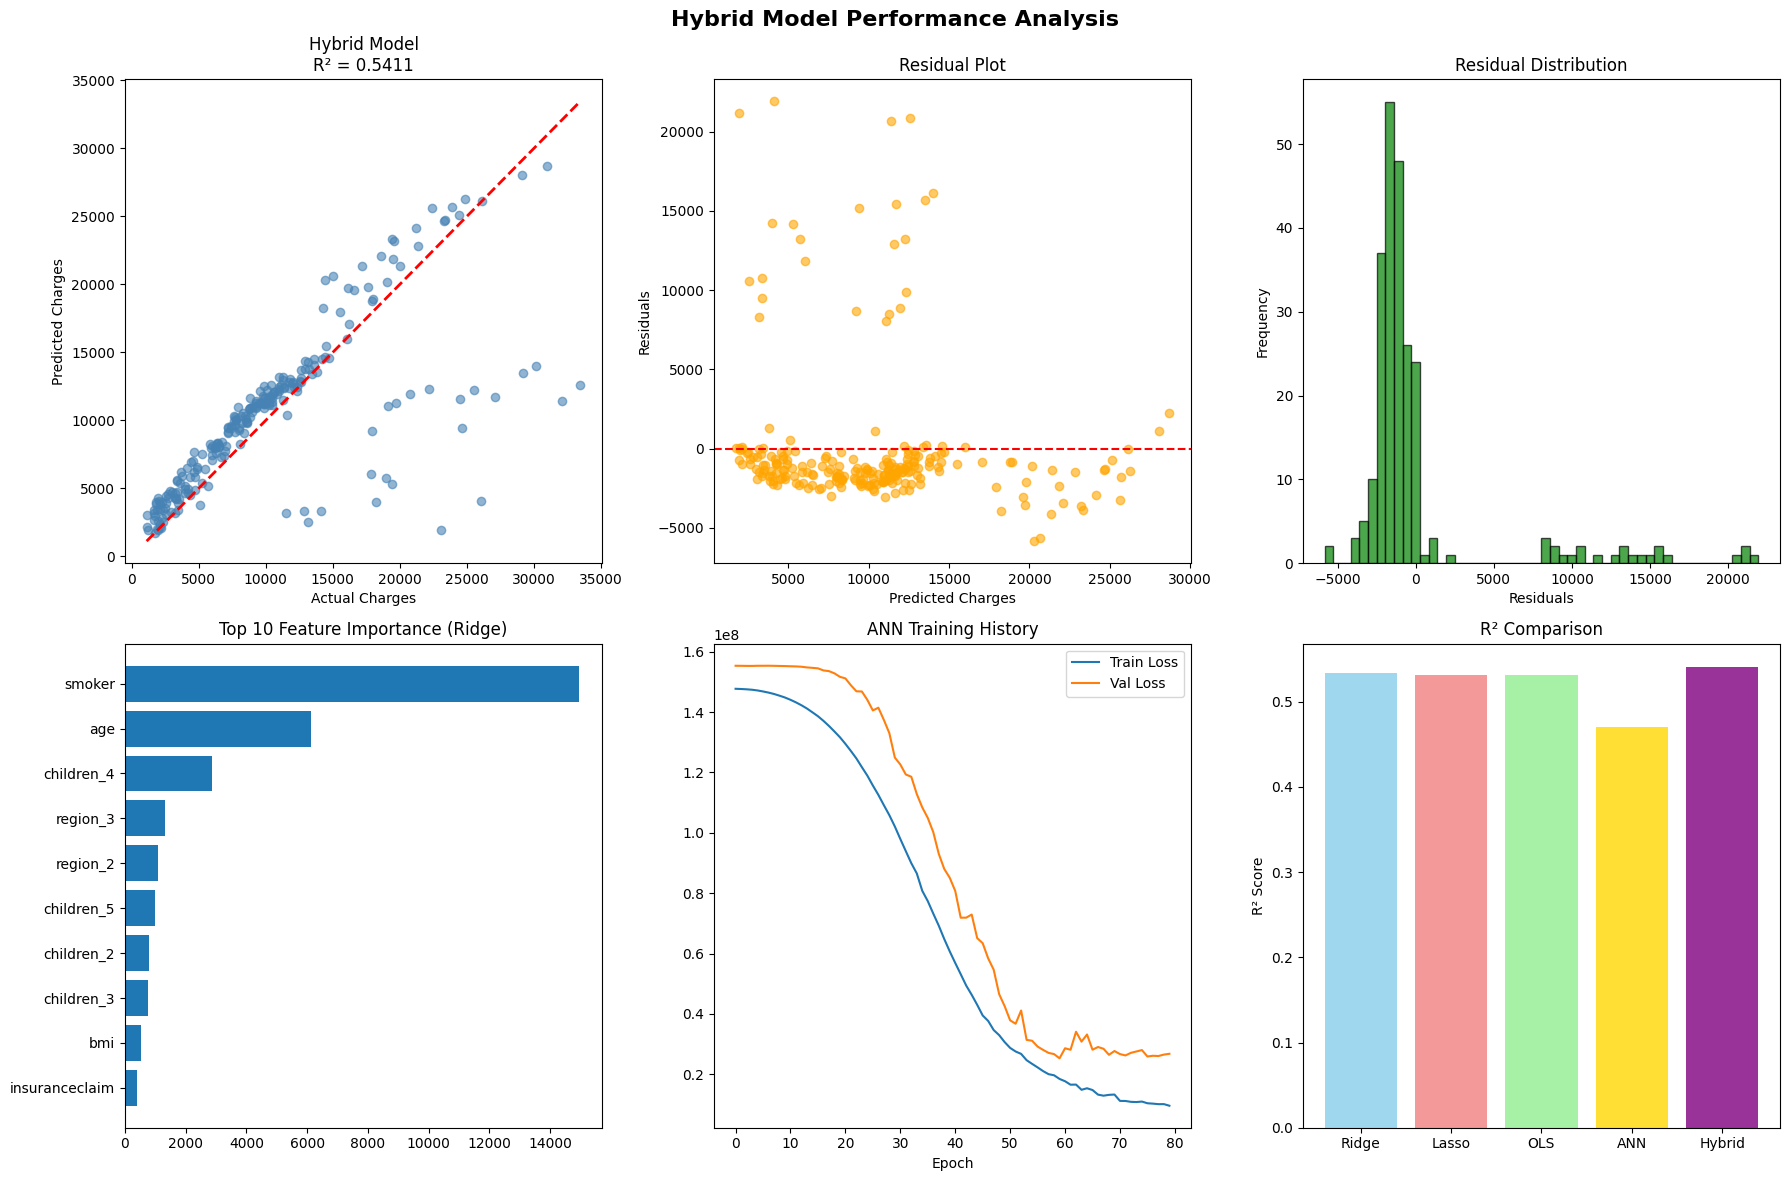

In [ ]:


fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Hybrid Model Performance Analysis', fontsize=16, fontweight='bold')

# 1. Actual vs Predicted
axes[0,0].scatter(y_test, hybrid_pred, alpha=0.6, color='steelblue')
axes[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0,0].set_xlabel('Actual Charges')
axes[0,0].set_ylabel('Predicted Charges')
axes[0,0].set_title(f'Hybrid Model\nR² = {hybrid_r2:.4f}')

# 2. Residuals
residuals = y_test - hybrid_pred
axes[0,1].scatter(hybrid_pred, residuals, alpha=0.6, color='orange')
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Predicted Charges')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Residual Plot')

# 3. Prediction Error Distribution
axes[0,2].hist(residuals, bins=50, alpha=0.7, color='green', edgecolor='black')
axes[0,2].set_xlabel('Residuals')
axes[0,2].set_ylabel('Frequency')
axes[0,2].set_title('Residual Distribution')

# 4. Feature Importance (from Ridge)
feature_importance = np.abs(ridge.coef_)
top_features = np.argsort(feature_importance)[-10:]
axes[1,0].barh([X.columns[i] for i in top_features],
               feature_importance[top_features])
axes[1,0].set_title('Top 10 Feature Importance (Ridge)')

# 5. Training History
axes[1,1].plot(ann_history.history['loss'], label='Train Loss')
axes[1,1].plot(ann_history.history['val_loss'], label='Val Loss')
axes[1,1].set_title('ANN Training History')
axes[1,1].legend()
axes[1,1].set_xlabel('Epoch')

# 6. Model Comparison
models = ['Ridge', 'Lasso', 'OLS', 'ANN', 'Hybrid']
r2_scores = [r2_score(y_test, ridge_pred), r2_score(y_test, lasso_pred),
            r2_score(y_test, ols_pred), r2_score(y_test, ann_pred), hybrid_r2]
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold', 'purple']
axes[1,2].bar(models, r2_scores, color=colors, alpha=0.8)
axes[1,2].set_title('R² Comparison')
axes[1,2].set_ylabel('R² Score')

plt.tight_layout()
plt.show()